In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


/kaggle/input/train.csv
/kaggle/input/test.csv
/kaggle/input/description.md
/kaggle/input/sample_submission.csv
/kaggle/input/train.csv.zip
/kaggle/input/test.csv.zip
/kaggle/input/sample_submission.csv.zip
/kaggle/input/tweet-sentiment-extraction/train.csv
/kaggle/input/tweet-sentiment-extraction/test.csv
/kaggle/input/tweet-sentiment-extraction/description.md
/kaggle/input/tweet-sentiment-extraction/sample_submission.csv
/kaggle/input/tweet-sentiment-extraction/train.csv.zip
/kaggle/input/tweet-sentiment-extraction/test.csv.zip
/kaggle/input/tweet-sentiment-extraction/sample_submission.csv.zip


In [2]:
train_df = pd.read_csv("/kaggle/input/tweet-sentiment-extraction/train.csv")
train_df.head(5)


,textID,text,selected_text,sentiment
0,8d4ad58b45,eating breakfast getting ready to go to schoo...,eating breakfast getting ready to go to schoo...,negative
1,fdfe12a800,Going to fold laundry and then hit the sack. I...,I have boring saturday evenings,negative
2,5efd224f4e,happy mothers day to all im off to spend the...,happy,positive
3,5678f1f769,one of my favorite quotes ever,favorite,positive
4,706510b794,"yeah, that was my point >.< please dont make ...",worse,negative


In [3]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24732 entries, 0 to 24731
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         24732 non-null  object
 1   text           24731 non-null  object
 2   selected_text  24731 non-null  object
 3   sentiment      24732 non-null  object
dtypes: object(4)
memory usage: 773.0+ KB


In [4]:
train_df.dropna(inplace=True)


In [5]:
def jacquard_f(text1, text2):
    text1 = set(text1.lower().split())
    text2 = set(text2.lower().split())
    inter = text1.intersection(text2)
    return len(inter)/(len(text1) + len(text2) - len(inter))
    


In [6]:
jacquard_values = [] 
for ind, row in train_df.iterrows():
    s1 = row.text
    s2 = row.selected_text
    jacquard_values.append([s1, s2, jacquard_f(s1, s2)])
jacquard = pd.DataFrame(jacquard_values, columns=["text","selected_text","jac"])
train_df = train_df.merge(jacquard, how="outer",on="text")
train_df.head(3)


,textID,text,selected_text_x,sentiment,selected_text_y,jac
0,0fab80d6b2,\tREALLY?? oh.. sorry yall lol,sorry,negative,sorry,0.200000
1,8106d4c6fa,_beckett Thanks so much !,beckett Thanks,positive,beckett Thanks,0.166667
2,3792c7b13e,You`ll be missed!! Bring me back a key...,You`ll be miss,negative,You`ll be miss,0.222222


/tmp/ipykernel_11/640910868.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  p1=sns.kdeplot(train_df[train_df['sentiment']=='positive']['jac'], shade=True, color="r")
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_11/640910868.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  p2=sns.kdeplot(train_df[train_df['sentiment']=='negative']['jac'], shade=True, color="b")
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf valu

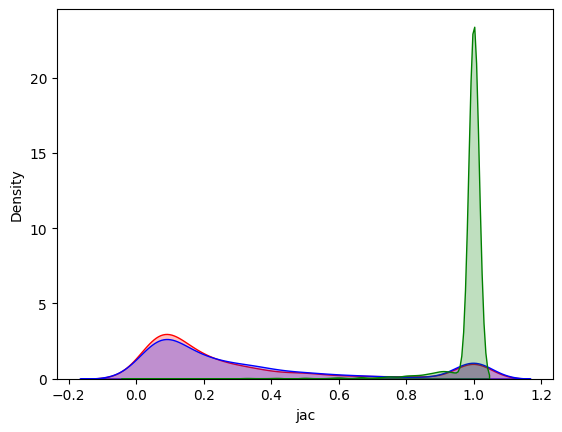

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

p1=sns.kdeplot(train_df[train_df['sentiment']=='positive']['jac'], shade=True, color="r")
p2=sns.kdeplot(train_df[train_df['sentiment']=='negative']['jac'], shade=True, color="b")
p3=sns.kdeplot(train_df[train_df['sentiment']=='neutral']['jac'], shade=True, color="g")


In [8]:
train_df['num_words_text']= train_df['text'].apply(lambda x: len(str(x).split()))


In [9]:
less_three = train_df[train_df['num_words_text']<=2]
less_three.groupby('sentiment').mean()['jac']
less_three.head(5)


TypeError: agg function failed [how->mean,dtype->object]

In [10]:
from nltk.corpus import stopwords
stopword = stopwords.words('english')


In [11]:
import re
#
import string
def clean_text(text):
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    text = text.split()
    words = [t for t in text if t not in stopword]
    return words
train_df['list_words'] = train_df['text'].apply(lambda x:clean_text(x))
train_df['list_words_selected'] = train_df['selected_text_x'].apply(lambda x:clean_text(x))


In [12]:
train_df['list_words'].head(3)


0            [really, oh, sorry, yall, lol]
1                   [beckett, thanks, much]
2    [youll, missed, bring, back, keychain]
Name: list_words, dtype: object

In [13]:
from collections import Counter
#train_df['list_words']=train_df['selected_text_x'].apply(lambda x:str(x).split())
top_words_text = Counter([item for sublist in train_df['list_words'] for item in sublist])
#train_df['list_words_text']=train_df['text'].apply(lambda x:str(x).split())
top_words_selected_text = Counter([item for sublist in train_df['list_words_selected'] for item in sublist])


In [14]:
positives = train_df[train_df['sentiment']=='positive']
negatives = train_df[train_df['sentiment']=='negative']
neutrals = train_df[train_df['sentiment']=='neutral']


In [15]:
top = Counter([item for sublist in positives['list_words'] for item in sublist])
temp_positive = pd.DataFrame(top.most_common(20))
temp_positive.columns = ['Common_words','count']
temp_positive


,Common_words,count
0,day,1097
1,good,948
2,love,767
3,happy,758
4,im,662
5,mothers,557
6,thanks,504
7,great,414
8,like,375
9,hope,357


In [16]:
top = Counter([item for sublist in negatives['list_words'] for item in sublist])
temp_negative = pd.DataFrame(top.most_common(20))
temp_negative.columns = ['Common_words','count']
temp_negative


,Common_words,count
0,im,1127
1,like,429
2,cant,422
3,dont,420
4,get,395
5,miss,379
6,sad,353
7,go,348
8,work,344
9,sorry,308


In [17]:
top = Counter([item for sublist in neutrals['list_words'] for item in sublist])
temp_neutral = pd.DataFrame(top.most_common(20))
temp_neutral.columns = ['Common_words','count']
temp_neutral


,Common_words,count
0,im,916
1,get,560
2,go,527
3,day,456
4,dont,442
5,work,434
6,going,426
7,like,413
8,got,407
9,lol,404


In [18]:
import plotly.express as px
fig = px.treemap(temp_positive, path=['Common_words'], values='count',title='Common Postive Words')
fig.show()
fig = px.treemap(temp_negative, path=['Common_words'], values='count',title='Common Negative Words')
fig.show()
fig = px.treemap(temp_neutral, path=['Common_words'], values='count',title='Common Neutral Words')
fig.show()


In [19]:
def get_unique_words(sentiment,numwords,raw_words):
    #Get unique words belonging to categories other than given sentiment
    other_words = []
    for item in train_df[train_df.sentiment != sentiment]['list_words']:
        for word in item:
            other_words.append(word)
    other_words= list(set(other_words))
    category_words = [x for x in raw_words if x not in other_words]
    newcounter = Counter()
    for item in train_df[train_df.sentiment == sentiment]['list_words']:
        for word in item:
            newcounter[word] += 1
    keep = list(category_words)
    for word in list(newcounter):
        if word not in keep:
            del newcounter[word]
    unique_words = pd.DataFrame(newcounter.most_common(numwords), columns = ['words','count'])
    return unique_words


In [20]:
raw_text = [word for word_list in train_df['list_words'] for word in word_list]
unique_positive= get_unique_words('positive', 20, raw_text)
unique_negative= get_unique_words('negative', 20, raw_text)
unique_neutral= get_unique_words('neutral', 20, raw_text)
unique_positive


,words,count
0,congratulations,25
1,appreciated,8
2,brilliant,8
3,lovin,8
4,thnx,8
5,greetings,7
6,shared,7
7,presents,7
8,blessings,6
9,mothersday,6


In [21]:
train_df = pd.read_csv('/kaggle/input/tweet-sentiment-extraction/train.csv')
test_df = pd.read_csv('/kaggle/input/tweet-sentiment-extraction/test.csv')
train_df['text_length'] = train_df['text'].apply(lambda x:len(str(x).split())) 
train_df = train_df[train_df['text_length']>=3]


In [22]:
def format_data(sentiment):
    formatted_data = []
    for index, row in train_df.iterrows():
        if row.sentiment == sentiment:
            selected_text = row.selected_text
            text = row.text
            start = text.find(selected_text)
            end = start + len(selected_text)
            formatted_data.append((text, {"entities": [[start, end, 'selected_text']]}))
    return formatted_data


In [23]:
def train(train_data, output_path, n_iter=20, model=None):
    if model is not None:
        nlp = spacy.load(output_path) 
    else:
        nlp = spacy.blank("en")
    
    if "ner" not in nlp.pipe_names:
        ner = nlp.create_pipe("ner")
        nlp.add_pipe(ner, last=True)
    else:
        ner = nlp.get_pipe("ner")
    
    for _, annotations in train_data:
        for ent in annotations.get("entities"):
            ner.add_label(ent[2])

    other_pipes = [pipe for pipe in nlp.pipe_names if pipe != "ner"]
    with nlp.disable_pipes(*other_pipes): 
        if model is None:
            nlp.begin_training()
        else:
            nlp.resume_training()


        for itn in tqdm(range(n_iter)):
            random.shuffle(train_data)
            batches = minibatch(train_data, size=compounding(4.0, 500.0, 1.001))    
            losses = {}
            for batch in batches:
                texts, annotations = zip(*batch)
                nlp.update(texts,  # batch of texts
                            annotations,  # batch of annotations
                            drop=0.5,   # dropout - make it harder to memorise data
                            losses=losses, 
                            )
            print("Losses", losses)
    nlp.meta["name"] = "st_ner"
    nlp.to_disk(output_path)


In [24]:
import spacy
from tqdm import tqdm
import random
from spacy.util import minibatch, compounding
sentiment = 'positive'
train_data_positive = format_data(sentiment)
train(train_data_positive, 'positive', n_iter=3, model=None)


ValueError: [E966] `nlp.add_pipe` now takes the string name of the registered component factory, not a callable component. Expected string, but got <spacy.pipeline.ner.EntityRecognizer object at 0x7ffeb1cdd4d0> (name: 'None').

- If you created your component with `nlp.create_pipe('name')`: remove nlp.create_pipe and call `nlp.add_pipe('name')` instead.

- If you passed in a component like `TextCategorizer()`: call `nlp.add_pipe` with the string name instead, e.g. `nlp.add_pipe('textcat')`.

- If you're using a custom component: Add the decorator `@Language.component` (for function components) or `@Language.factory` (for class components / factories) to your custom component and assign it a name, e.g. `@Language.component('your_name')`. You can then run `nlp.add_pipe('your_name')` to add it to the pipeline.

In [25]:
sentiment = 'negative'
train_data_negative = format_data(sentiment)
train(train_data_negative, 'negative', n_iter=3, model=None)


ValueError: [E966] `nlp.add_pipe` now takes the string name of the registered component factory, not a callable component. Expected string, but got <spacy.pipeline.ner.EntityRecognizer object at 0x7ffeb1cdf3e0> (name: 'None').

- If you created your component with `nlp.create_pipe('name')`: remove nlp.create_pipe and call `nlp.add_pipe('name')` instead.

- If you passed in a component like `TextCategorizer()`: call `nlp.add_pipe` with the string name instead, e.g. `nlp.add_pipe('textcat')`.

- If you're using a custom component: Add the decorator `@Language.component` (for function components) or `@Language.factory` (for class components / factories) to your custom component and assign it a name, e.g. `@Language.component('your_name')`. You can then run `nlp.add_pipe('your_name')` to add it to the pipeline.

In [26]:
def predict_entities(text, model):
    doc = model(text)
    ent_array = []
    for ent in doc.ents:
        start = text.find(ent.text)
        end = start + len(ent.text)
        new_int = [start, end, ent.label_]
        if new_int not in ent_array:
            ent_array.append([start, end, ent.label_])
    selected_text = text[ent_array[0][0]: ent_array[0][1]] if len(ent_array) > 0 else text
    return selected_text


In [27]:
predicted_selected_text = []
model_pos = spacy.load('positive')
model_neg = spacy.load('negative')
        
for index, row in test_df.iterrows():
    text = row.text
    output_str = ""
    if row.sentiment == 'neutral' or len(text.split()) <= 2:
        predicted_selected_text.append(text)
    elif row.sentiment == 'positive':
        predicted_selected_text.append(predict_entities(text, model_pos))
    else:
        predicted_selected_text.append(predict_entities(text, model_neg))
        
test_df['selected_text'] = predicted_selected_text


OSError: [E050] Can't find model 'positive'. It doesn't seem to be a Python package or a valid path to a data directory.

In [28]:
submission_df = pd.read_csv('/kaggle/input/tweet-sentiment-extraction/sample_submission.csv')
submission_df['selected_text'] = test_df['selected_text']
submission_df.to_csv("submission.csv", index=False)
submission_df.head(10)


KeyError: 'selected_text'